<a href="https://colab.research.google.com/github/zia207/High_Performance_Computing_R/blob/main/Notebook/02_01_02_hpc_bigdata_wrangling_datatable_r.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![R Banner](https://drive.google.com/uc?id=1LhRCsnq8s3y0M76oN3-GEUfWQVL_yUv-)



# Data Wrangling with {data.table}

The [data.table](https://github.com/Rdatatable/data.table) is a powerful
and widely used package in the R programming language. It provides an
alternative to the default data.frame for handling tabular data. One of
the primary reasons for its popularity is its exceptional performance,
especially when dealing with large datasets. The package’s concise
syntax is another benefit of using data.table. It allows for complex
data manipulations and transformations with less code, making it a
favorite among Data Scientists.


{Data.table} is one of the most downloaded packages in R. It’s
well-liked by developers and analysts, who consider it one of the best
things that has happened to the R programming language in terms of
speed. The package’s syntax differs somewhat from the regular R
data.frame. However, it is quite intuitive once you get the hang of it.
This makes it easy to use and understand, and once you learn it, you may
never want to revert to using the base R data.frame syntax. In summary,
data.table is a powerful, fast, and intuitive package for managing
tabular data in R. Its popularity among Data Scientists is a testament
to its usefulness and efficiency. With data.table, you can write less
code and achieve faster results, making it a go-to package for working
with large datasets.


## Setup R in Python Runtime - Install {rpy2}

{rpy2} allows running R code in Colab Python runtime via `%%R` magic.


In [ ]:
!pip uninstall rpy2 -y
!pip install rpy2==3.5.1
%load_ext rpy2.ipython


## Mount Google Drive

Mount Google Drive if your data or R library folder is stored there.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


## Check and Install Required R Packages

In [ ]:
%%R
packages <- c(
          'tidyverse',
          'data.table',
          'arrow'

)

``` r
#| warning: false
#| error: false

# Install missing packages
# Install missing packages
new.packages <- packages[!(packages %in% installed.packages(lib='drive/My Drive/R/')[,"Package"])]
if(length(new.packages)) install.packages(new.packages, lib='drive/My Drive/R/')
```



### Verify Installation

In [ ]:
%%R
# Verify installation
cat("Installed packages:\n")

Installed packages:

 tidyverse data.table      arrow 
      TRUE       TRUE       TRUE 

### Load Packages

In [ ]:
%%R
# set library path
.libPaths('drive/My Drive/R')
# Verify installation
cat("Installed packages:\n")
print(sapply(packages, requireNamespace, quietly = TRUE))

### Check Loaded Packages

In [ ]:
%%R
# Check loaded packages
cat("Successfully loaded packages:\n")

Successfully loaded packages:

 [1] "package:arrow"      "package:data.table" "package:lubridate" 
 [4] "package:forcats"    "package:stringr"    "package:dplyr"     
 [7] "package:purrr"      "package:readr"      "package:tidyr"     
[10] "package:tibble"     "package:ggplot2"    "package:tidyverse" 
[13] "package:stats"      "package:graphics"   "package:grDevices" 
[16] "package:utils"      "package:datasets"   "package:methods"   
[19] "package:base"      

### Data

The dataset is in Parquet format, which DuckDB can query directly
without loading into memory. For reproducibility:

-   Download the January 2023 data from:
    <https://d37ci07v2hxiua.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet>
    (about 47 MB, ~3 million rows).

-   We saved it to a local folder, e.g.,
    `/home/zia207/Dropbox/WebSites/R_Website/Quarto_Projects/R_Beginner/Data/yellow_tripdata_2023-01.parquet`.

-   We’ll also use the Taxi Zone Lookup CSV for joins: Download from
    <https://s3.amazonaws.com/nyc-tlc/misc/taxi+_zone_lookup.csv>.

The dataset includes columns like `VendorID`, `tpep_pickup_datetime`,
`tpep_dropoff_datetime`, `passenger_count`, `trip_distance`,
`PULocationID`, `DOLocationID`, `fare_amount`, `total_amount`, etc.

All data set use in this exercise can be downloaded from my
[Dropbox](https://www.dropbox.com/scl/fo/wcfu9fgh91gxhwsl3wy6h/APeXbf8IR1jl6yUtUHWZhak?rlkey=ma1qqo0xj00hwegv5u1s97y6m&dl=0)
accounts.

### Importing Data (parquet file)

We will use `open_dataset()` function of **arrow** package to import
`yellow_tripdata_2023.parquet` as a **lazy** data. The `open_dataset()`
function is used to read in a dataset from a specified file path or URL.
It is particularly useful for working with large datasets that may not
fit into memory all at once. The function returns a lazy dataset object
that can be manipulated using dplyr-style syntax, allowing for efficient
filtering, grouping, and summarization of the data without loading the
entire dataset into memory. This makes it an ideal choice for working
with big data in R.

In [ ]:
%%R
dataFolder<-"/home/zia207/WebSites/R_Website/High_Performance_Computing_R/R_Markdown/Data/"
# Load January 2023 data
ds <- open_dataset(paste0(dataFolder, "yellow_tripdata_2023.parquet"))
# print(object.size(as.data.table(ds)), units = "GB") # 4.9 GB file size

### Importing Lookup Data (CSV file)

We will use `fread()` function of **data.table** package to import
`taxi_zone_lookup.csv` as a **tidy** data. When it comes to working with
**data.tables**, it’s important to realize that the process is different
from working with **data.frames**. Before diving in and using this
package, it’s essential to understand the differences between the two.
One of the most useful functions of data.table is `fread()`, which is a
faster and more efficient version of `read.csv()`. It’s worth noting
that `fread()` can work with local files on your computer, as well as
files hosted on the internet. In fact, it’s been shown to be at least 20
times faster than `read.csv()`, which can be a huge advantage when
dealing with large datasets. This dataset is stored as a csv file and
can be easily imported using `fread()`. By using this function, you’ll
be able to import the data quickly and efficiently into your R
environment.

In [ ]:
%%R
zones <- fread(paste0(dataFolder, "taxi_zone_lookup.csv")) |>
  glimpse()

Rows: 265
Columns: 4
$ LocationID   <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17…
$ Borough      <chr> "EWR", "Queens", "Bronx", "Manhattan", "Staten Island", "…
$ Zone         <chr> "Newark Airport", "Jamaica Bay", "Allerton/Pelham Gardens…
$ service_zone <chr> "EWR", "Boro Zone", "Boro Zone", "Yellow Zone", "Boro Zon…

### Convert data.frame to data.table

When data is imported, it can be stored in various formats. In this
case, the data is stored as a data.table. It is worth noting that a
`data.table` is a type of data structure that inherits from the
data.frame class. This means that the data.table itself can be
considered a data.frame. By default, `data.tables` have some unique
features that make them efficient when working with large datasets. For
example, they have optimized memory usage and fast operations for
querying and processing data.

You can use `as.data.table()` or `setDT()` to convert data.frame to
data.table:

In [ ]:
%%R
dt <- ds %>%
  # data for January 2023
  filter(tpep_pickup_datetime >= as.Date("2023-01-01") & tpep_pickup_datetime < as.Date("2023-02-01")) |>
  collect()  |>
  as.data.table()

In [ ]:
%%R
# Check dataset size
print(object.size(dt), units = "GB")

0.4 Gb

### Check data dimensions

In [ ]:
%%R
dim(dt)

[1] 3066726      19

### Creating a new column

One of the key features of data.table is the ability to create a new
column by assigning values to it within the square brackets. This can be
done using the `:=` operator, which allows you to assign a value to a
column by reference.

In [ ]:
%%R
# Feature Engineering
dt[, trip_duration := as.numeric(difftime(tpep_dropoff_datetime, tpep_pickup_datetime, units = "mins"))]
dt[trip_distance > 0, fare_per_mile := fare_amount / trip_distance]
dt[, pickup_hour := hour(tpep_pickup_datetime)]
dt[, time_of_day := fcase(
  pickup_hour >= 6 & pickup_hour < 12, "Morning",
  pickup_hour >= 12 & pickup_hour < 18, "Afternoon",
  pickup_hour >= 18 & pickup_hour < 22, "Evening",
  default = "Night"
)]
dt[, is_weekend := wday(as.Date(tpep_pickup_datetime)) %in% c(1, 7)]

### Select: Specific columns

In [ ]:
%%R
# Select: Specific columns
selected_dt <- dt[, .(tpep_pickup_datetime, passenger_count, trip_distance, fare_amount, PULocationID)]
names(selected_dt)

[1] "tpep_pickup_datetime" "passenger_count"      "trip_distance"       
[4] "fare_amount"          "PULocationID"        

### Join with zones

In [ ]:
%%R
# Join with zones
joined_dt <- dt[zones, on = .(PULocationID = LocationID), nomatch = 0]

### Filter and Agrregates

In [ ]:
%%R
# Filter: Passenger count > 2 and trip_distance > 5
filtered_dt <- dt[passenger_count > 2 & trip_distance > 5]
cat("Number of filtered rows:", filtered_dt[, .N], "\n")

Number of filtered rows: 40221 

In [ ]:
%%R
# Filter and Select: Manhattan trips with fare_amount > 20
manhattan_dt <- joined_dt[Borough == "Manhattan" & fare_amount > 20,
                          .(tpep_pickup_datetime, trip_distance, fare_amount, Borough)]
head(manhattan_dt)

   tpep_pickup_datetime trip_distance fare_amount   Borough
                 <POSc>         <num>       <num>    <char>
1:  2023-01-08 09:03:30          0.00        31.2 Manhattan
2:  2023-01-08 09:26:29          7.22        38.0 Manhattan
3:  2023-01-08 13:44:29          8.97        41.5 Manhattan
4:  2023-01-08 13:38:23          5.80        32.4 Manhattan
5:  2023-01-16 13:34:18          6.74        32.4 Manhattan
6:  2023-01-16 14:36:19          4.20        21.9 Manhattan

In [ ]:
%%R
# Filter and Aggregate: Long trips (>10 miles) by Borough
long_trips_dt <- joined_dt[trip_distance > 10,
                           .(avg_fare = mean(fare_amount, na.rm = TRUE),
                             trip_count = .N),
                           by = Borough]
head(long_trips_dt)

         Borough avg_fare trip_count
          <char>    <num>      <int>
1:           EWR 81.62581         31
2:         Bronx 50.64914        818
3:     Manhattan 61.91102      65249
4: Staten Island 62.36416        185
5:        Queens 64.63434     167774
6:      Brooklyn 53.81423       2173

### Summary Statistics

Data.table is a powerful package in R that offers an efficient and fast
way to perform operations on large datasets. One of its main features is
the ability to summarize data using various functions such as `sum()`,
`mean()`, `count()`, and many others. To use these functions, you simply
need to enclose them within square brackets `([ ])`. This will allow you
to summarize the data based on certain criteria or conditions, and
quickly retrieve important information such as the total sum, average,
or count of a specific column or group of columns. By utilizing
data.table, you can easily analyze your data in a more efficient and
streamlined manner.

In [ ]:
%%R
# Mean of fare_amount
suppressWarnings(dt[, mean(fare_amount, na.rm = TRUE)])

[1] 18.36691

[1] 12.8

For multiple variables:

In data.table, you can calculate the mean of multiple columns by
specifying them within the `j` argument and using the `lapply()`
function to apply the `mean()` function across those columns. Here’s an
example:

In [ ]:
%%R
# Mean of multiple columns
suppressWarnings(dt[, lapply(.SD, mean, na.rm = TRUE),
                    .SDcols = c("fare_amount", "trip_distance", "passenger_count")])

   fare_amount trip_distance passenger_count
         <num>         <num>           <num>
1:    18.36691      3.847351        1.362536

Here, `.SD` refers to the Subset of Data and `.SDcols` specifies the
columns on which the operation needs to be performed (in this case,
columns “LBC_Rate”, “Smoking”, “PM25”). The `lapply()` function applies
the mean() function across these selected columns to calculate their
mean

You can compute both the mean and standard deviation of multiple columns
simultaneously within a data.table in R.

In [ ]:
%%R
# Summary statistics (mean and sd) for multiple columns
summary_stats <- suppressWarnings(dt[, lapply(.SD,
                                             function(x) c(mean = mean(x, na.rm = TRUE),
                                                           sd = sd(x, na.rm = TRUE))),
                                    .SDcols = c("fare_amount", "trip_distance", "passenger_count")])
print(summary_stats)

   fare_amount trip_distance passenger_count
         <num>         <num>           <num>
1:    18.36691      3.847351       1.3625359
2:    17.80755    249.585383       0.8961282

### Group by

In data.table, you can use the `by` argument to group your data based on
one or more columns, and then calculate summary statistics for each
group. This is useful when you want to perform calculations on subsets
of your data.

In [ ]:
%%R
# Group By: Total trips and average distance by Borough
borough_group_dt <- joined_dt[, .(total_trips = .N,
                                  avg_distance = mean(trip_distance, na.rm = TRUE)),
                              by = Borough]
print(borough_group_dt)

         Borough total_trips avg_distance
          <char>       <int>        <num>
1:           EWR         408     1.602549
2:        Queens      286635    12.320686
3:         Bronx        4162     5.296593
4:     Manhattan     2715344     2.883812
5: Staten Island         341    11.356774
6:      Brooklyn       18075     5.677719
7:       Unknown       41761     7.363166

### Relocate or column reordering

In data.table, all `set()` functions change their input by reference.
That is, no copy is made at all, other than temporary working memory
which is as large as one column. The only other data.table operator that
modifies input by reference is :=.

Now we will organize DIVISION_FIPS, DIVISION_NAME, STATE_FIPS,
STATE_NAME, DIVISION_NAME, YEAR, MT with `setcolorder()` function.

In [ ]:
%%R
# Derive pickup_year from tpep_pickup_datetime

joined_dt[, pickup_year := year(tpep_pickup_datetime)]

# Reorder columns
suppressWarnings(setcolorder(joined_dt,
                             c("PULocationID",
                               "Borough",
                               "DOLocationID",
                               "Zone",
                               "pickup_year",
                               "fare_amount")))

# Display first few rows
head(dt)

   VendorID tpep_pickup_datetime tpep_dropoff_datetime passenger_count
      <int>               <POSc>                <POSc>           <num>
1:        1  2023-01-08 08:48:48   2023-01-08 08:51:58               1
2:        1  2023-01-08 08:55:57   2023-01-08 09:02:27               1
3:        2  2023-01-08 08:04:43   2023-01-08 08:15:40               5
4:        2  2023-01-08 08:29:04   2023-01-08 08:43:32               5
5:        2  2023-01-08 08:48:43   2023-01-08 08:59:29               5
6:        2  2023-01-08 09:01:01   2023-01-08 09:12:01               5
   trip_distance RatecodeID store_and_fwd_flag PULocationID DOLocationID
           <num>      <num>             <char>        <int>        <int>
1:          0.50          1                  N          239          239
2:          0.90          1                  N          239          143
3:          1.38          1                  N           68          234
4:          2.59          1                  N          237        

### Rename

`setnames()` operates on data.table and data.frame not other types like
list and vector. It can be used to change names by name with built-in
checks and warnings

In [ ]:
%%R
# Rename PULocationID to PICKUP_ZONE_ID
suppressWarnings(setnames(joined_dt, "PULocationID", "PICKUP_ZONE_ID"))

### Pivot wider

The `dcast()` function is a highly efficient data reshaping tool
provided by the data.table package. It is used for converting long-form
data into wide-form data, and it can handle very large data sets with
ease.

One of the main advantages of using `dcast()` is its speed and memory
efficiency due to its optimized algorithms, the function is capable of
handling large data sets in RAM without slowing down or causing memory
issues. This makes it an excellent choice for data analysts and
scientists who work with large-scale data.

Another advantage of `dcast()` is its ability to handle multiple
value.var columns. This means that users can easily cast multiple
columns of their dataset simultaneously, without having to perform
multiple reshaping operations. Furthermore, the function supports
multiple functions to fun.aggregate, which allows users to compute
multiple summary statistics on their data at once.

Overall, `dcast()` is a powerful and efficient tool that can greatly
simplify the data reshaping process for users working with large and
complex data sets.

In [ ]:
%%R
# Pivot 1: fare_amount by pickup_year and Borough (no aggregation)
suppressWarnings(
  joined_dt |>
    dcast(pickup_year ~ Borough,
          value.var = "fare_amount") |>
    glimpse()
)

Rows: 2
Columns: 8
$ pickup_year     <int> 2022, 2023
$ Bronx           <int> 34, 4128
$ Brooklyn        <int> 862, 17213
$ EWR             <int> 0, 408
$ Manhattan       <int> 20602, 2694742
$ Queens          <int> 832, 285803
$ `Staten Island` <int> 2, 339
$ Unknown         <int> 306, 41455

`dcast()` function supports multiple functions to `fun.aggregate`, which
allows users to compute multiple summary statistics on their data at
once.

In [ ]:
%%R
# Pivot 2: Mean fare_amount by pickup_year and Borough
dt_wider <- suppressWarnings(
  dcast(joined_dt,
        pickup_year ~ Borough,
        fun.aggregate = mean,
        value.var = "fare_amount")
)
head(dt_wider)

Key: <pickup_year>
   pickup_year    Bronx Brooklyn     EWR Manhattan   Queens Staten Island
         <int>    <num>    <num>   <num>     <num>    <num>         <num>
1:        2022 29.76265 27.19589     NaN  17.40432 39.34421       0.00000
2:        2023 30.24673 26.78900 87.8423  14.75521 50.01433      49.03062
    Unknown
      <num>
1: 25.11912
2: 29.15654

### Pivot longer

In R’s data.table, it’s possible to transform wide data into long format
using the `melt()` function. This function is useful for reshaping data
when it’s needed to transform a dataset into a format that is more
suitable for analysis or visualization. To use the `melt()` function,
you first need to specify the data.table object that contains the data
you want to reshape. Then, you need to set the variables that you want
to retain as the `id.vars` argument, which will keep these variables in
the reshaped dataset. Finally, you will need to specify the variables
that you want to reshape as the `measure.vars` argument, which will be
used to create the new variables in the reshaped dataset.

The `melt()` function can be used to pivot a data frame from a wide
format to a long format.

In [ ]:
%%R
# Create wide-format table: mean fare_amount by pickup_year and Borough
dt_wider <- suppressWarnings(
  dcast(joined_dt,
        pickup_year ~ Borough,
        fun.aggregate = mean,
        value.var = "fare_amount")
)

# Melt to long format
dt_longer <- dt_wider |>
  melt(id.vars = "pickup_year",
       value.name = "fare_amount",
       variable.name = "Borough")

# Display first few rows
head(dt_longer)

   pickup_year  Borough fare_amount
         <int>   <fctr>       <num>
1:        2022    Bronx    29.76265
2:        2023    Bronx    30.24673
3:        2022 Brooklyn    27.19589
4:        2023 Brooklyn    26.78900
5:        2022      EWR         NaN
6:        2023      EWR    87.84230

### Visualize the data

      PULocationID payment_type avg_fare trip_count
             <int>        <int>    <num>      <int>
   1:          239            1 13.61268      69931
   2:           68            1 15.92646      59817
   3:          237            1 12.41361     119113
   4:          238            1 14.06361      49664
   5:          236            1 13.20226     112948
  ---                                              
1083:            3            0 46.11000          1
1084:          136            0 19.87500          2
1085:          235            0 39.94000          5
1086:          160            0 39.97000          1
1087:          250            0 50.36667          3

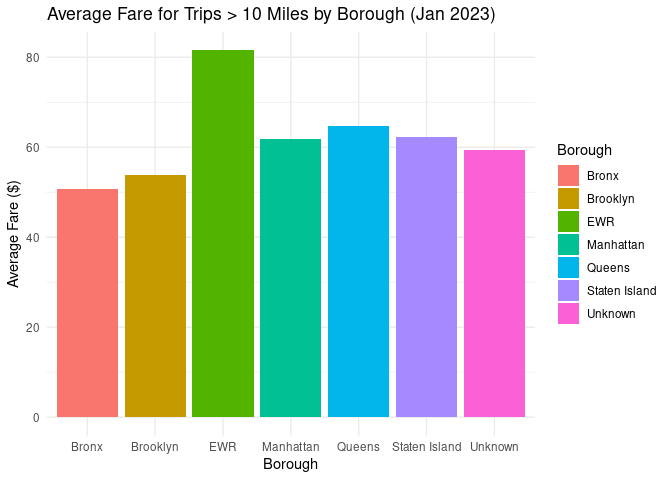

In [ ]:
%%R
# Example: Group by PULocationID and payment_type
group_dt <- dt[, .(avg_fare = mean(fare_amount, na.rm = TRUE),
                   trip_count = .N),
               by = .(PULocationID, payment_type)]
print(group_dt)

## Summary and Conclusion

This tutorial explores data wrangling using the R package “data.table,”
a powerful framework for managing large datasets. We will cover data
filtering, column selection, grouping, and summarization. Advanced
features include indexing, fast joins, and efficient data manipulation.
With data. table, you can handle large datasets and complex operations.
Practice with diverse datasets to streamline your workflows using the
power of data.table.

## References

1.  [Data Wrangling in R:
    data.table](https://clayford.github.io/dwir/dwr_10_datatable.html)

2.  [data.table in R – The Complete Beginners
    Guide](https://www.machinelearningplus.com/data-manipulation/datatable-in-r-complete-guide/)